# Natural Latents: Complete Comparison Notebook

**Every combination tested:** 2 embedding schemes (generic char n-gram vs.
domain-specific tokenizers) x 2 resampling states (with/without) x 5 loss
measures (KL divergence, cross-entropy, rank-based info gain, signed
log-likelihood ratio, and PMI as a deliberate negative control) x a combined
"mix" of all four real directional measures together.

## Thought process, up front

Every step shows you the actual data at that point -- not just a final
number. The design follows exactly what worked best earlier in this
project: losses are computed **independently per representation** (Lean,
LaTeX, Python lambda, Cayley table, natural language) and fed to a trained
classifier as separate features, rather than being pooled into one blended
score before comparison -- this "late fusion" approach was found to
roughly double accuracy versus blending representations together first.


## 0. Setup

In [1]:

import sys, os, json, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                              confusion_matrix, precision_recall_fscore_support)

sys.path.insert(0, '../src')
sys.path.insert(0, '../data')
from embeddings import make_generic_embedder, make_domain_specific_embedder
from resampling import NaturalLatentResampler
from losses import LOSS_FUNCTIONS

DATA_DIR = '../data'
np.random.seed(42)
random.seed(42)
print("Setup complete.")


Setup complete.


## 1. Load real data

Real equations and ground truth from the Equational Theories Project
(Terence Tao), via `corpaci/semantic-diffchecking`. Using a sample of 500
equations for a notebook that runs end-to-end in a reasonable time --
the full-scale version of this exact pipeline (4,612 equations, 21M pairs)
is documented separately; this notebook reproduces the same methodology
at a size you can run and inspect directly.


In [2]:

with open(os.path.join(DATA_DIR, 'equations_representations.json')) as f:
    all_equations = json.load(f)

# keep only equations with ALL 5 representations present
all_equations = [e for e in all_equations if e['natural_language'] is not None]
print(f"Equations with all 5 representations: {len(all_equations)}")

# FIX: random sample, not "first N" -- avoids any ordering bias in the source catalogue
SAMPLE_SIZE = 1200
random.seed(42)
sample_equations = random.sample(all_equations, SAMPLE_SIZE)
sample_nodes_list = [e['node'] for e in sample_equations]   # ordered list, used for direct pair generation below
sample_nodes = set(sample_nodes_list)
print(f"Using a RANDOM sample of {len(sample_equations)} equations for this notebook")

print("\n--- VIEW ON THE DATA: one real equation, all 5 representations ---")
example = sample_equations[10]
for k, v in example.items():
    print(f"{k:20s}: {str(v)[:100]}")


Equations with all 5 representations: 4612
Using a RANDOM sample of 1200 equations for this notebook

--- VIEW ON THE DATA: one real equation, all 5 representations ---
node                : 265
formal              : x = ((x ◇ y) ◇ y) ◇ z
lean                : example (G : Type u) [Magma G] : Prop := ∀ x y z : G, x = ((x ◇ y) ◇ y) ◇ z
latex               : x = ((x \diamond y) \diamond y) \diamond z
py_lambda           : lambda op, x, y, z: x == op(op(op(x, y), y), z)
py_cayley_table     : def law(table):
    n = len(table)
    return all(x == table[table[table[x][y]][y]][z] for x in rang
natural_language    : A single variable equals a sequence of three applications of a binary operation. The first applicati


In [3]:

# Generate pairs DIRECTLY from the sampled equations via the exact relationship
# matrix, instead of hoping a generic pre-sampled file happens to intersect with our
# sample -- gives far more usable pairs at essentially zero extra compute cost.
#
# IMPORTANT (found and fixed during testing): both directions of every sampled
# unordered pair are guaranteed to be included TOGETHER, not sampled independently.
# An earlier version of this cell included both directions in the available POOL
# but then sampled rows independently from that pool -- at typical sampling rates,
# under 5% of pairs actually had both directions land in the final sample, so the
# "symmetric measures give 0% weaker recall" claim (Section 6B) could not actually
# be demonstrated: most rows had no matching identical-feature/opposite-label
# counterpart to force that behavior. Sampling by UNORDERED pair first, then
# including both directions for every sampled pair, fixes this at the source.
from decode_matrix import load_matrix, relation_for

matrix, meta = load_matrix()
unordered_rows = []
for i, a in enumerate(sample_nodes_list):
    for b in sample_nodes_list[i+1:]:
        rel_ab = relation_for(matrix, a, b)
        rel_ba = relation_for(matrix, b, a)
        if rel_ab != 'unresolved' and rel_ba != 'unresolved':
            unordered_rows.append((a, b, rel_ab, rel_ba))

print(f"Unordered pairs available (both directions resolved): {len(unordered_rows):,}")

PAIR_SAMPLE_SIZE = 15000
N_UNORDERED = PAIR_SAMPLE_SIZE // 2
rng = random.Random(42)
sampled_unordered = rng.sample(unordered_rows, min(N_UNORDERED, len(unordered_rows)))

rows = []
for a, b, rel_ab, rel_ba in sampled_unordered:
    rows.append({'node_a': a, 'node_b': b, 'relation': rel_ab})
    rows.append({'node_a': b, 'node_b': a, 'relation': rel_ba})   # guaranteed mirror, same underlying pair

pairs = pd.DataFrame(rows).sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle row order only
print(f"Using {len(pairs):,} pairs for this notebook run ({len(sampled_unordered):,} unordered pairs x 2 directions)")
print(pairs['relation'].value_counts())
print("\n--- VIEW ON THE DATA: first 5 labeled pairs ---")
pairs.head()


Unordered pairs available (both directions resolved): 719,396
Using 15,000 pairs for this notebook run (7,500 unordered pairs x 2 directions)
relation
incomparable    5762
weaker          3815
stronger        3815
equivalent      1608
Name: count, dtype: int64

--- VIEW ON THE DATA: first 5 labeled pairs ---


,node_a,node_b,relation
0,2560,2335,weaker
1,3031,1384,weaker
2,4155,435,incomparable
3,2890,3443,incomparable
4,4473,1852,incomparable


## 2. Build BOTH embedding schemes

Generic (char n-grams, the scheme behind the ~46-47% result) and
domain-specific (a real tokenizer per representation type: Lean
keywords/symbols, actual Python syntax tokens via `tokenize`, LaTeX
commands, and word-level for natural language).


In [4]:

representations = {}
for view in ['lean', 'latex', 'py_lambda', 'py_cayley_table', 'natural_language']:
    representations[view] = {e['node']: e[view] for e in sample_equations}

print("--- VIEW: representations dict structure ---")
print("views:", list(representations.keys()))
print("equations per view:", len(representations['lean']))


--- VIEW: representations dict structure ---
views: ['lean', 'latex', 'py_lambda', 'py_cayley_table', 'natural_language']
equations per view: 1200


In [5]:

embed_generic = make_generic_embedder(char_ngrams=(2,4), max_features=500)
embed_domain = make_domain_specific_embedder(max_features=500)

resampler_generic = NaturalLatentResampler(embed_generic, ridge_alpha=1.0, n_components=8)
resampler_generic.fit_embeddings(representations)

resampler_domain = NaturalLatentResampler(embed_domain, ridge_alpha=1.0, n_components=8)
resampler_domain.fit_embeddings(representations)

print("--- VIEW: embedding dimensionality per view, both schemes ---")
for view in representations:
    print(f"{view:20s} generic={resampler_generic.view_matrices[view].shape}  "
          f"domain_specific={resampler_domain.view_matrices[view].shape}")


--- VIEW: embedding dimensionality per view, both schemes ---
lean                 generic=(1200, 361)  domain_specific=(1200, 19)
latex                generic=(1200, 220)  domain_specific=(1200, 10)
py_lambda            generic=(1200, 284)  domain_specific=(1200, 13)
py_cayley_table      generic=(1200, 393)  domain_specific=(1200, 23)
natural_language     generic=(1200, 500)  domain_specific=(1200, 452)


## 3. Correlation heatmap -- the finding that motivated "late fusion"

Earlier in this project we found the four formal representations
(Lean/LaTeX/Python-lambda/Cayley-table) correlate moderately with each
other, while natural language correlates close to zero with all of them.
Here's that finding, shown directly rather than just described.


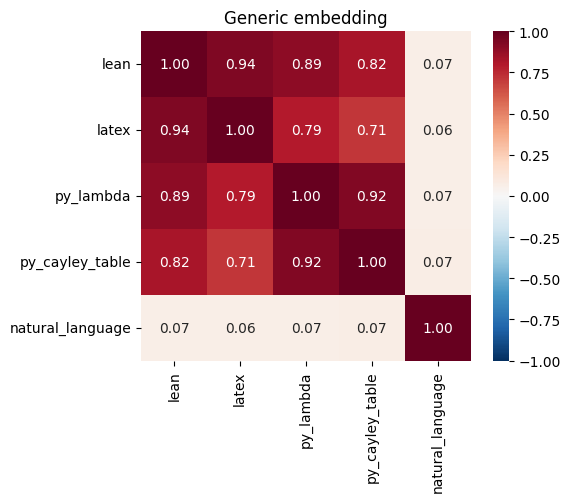


Natural language row (generic embedding): {'lean': np.float64(0.067), 'latex': np.float64(0.063), 'py_lambda': np.float64(0.068), 'py_cayley_table': np.float64(0.074), 'natural_language': np.float64(1.0)}


In [6]:

def view_correlation_heatmap(view_matrices, title):
    views = list(view_matrices.keys())
    # reduce each view to its mean-pooled scalar profile for a simple,
    # interpretable correlation: correlate each view's OWN pairwise distance
    # structure against every other view's pairwise distance structure
    from scipy.spatial.distance import pdist
    profiles = {v: pdist(view_matrices[v]) for v in views}
    corr = np.zeros((len(views), len(views)))
    for i, vi in enumerate(views):
        for j, vj in enumerate(views):
            corr[i,j] = np.corrcoef(profiles[vi], profiles[vj])[0,1]

    plt.figure(figsize=(6,5))
    sns.heatmap(corr, xticklabels=views, yticklabels=views, annot=True, fmt='.2f',
                cmap='RdBu_r', vmin=-1, vmax=1, square=True)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f'../outputs/correlation_heatmap_{title.replace(" ","_")}.png', dpi=100)
    plt.show()
    return views, corr

views, corr_generic = view_correlation_heatmap(resampler_generic.view_matrices, "Generic embedding")
print("\nNatural language row (generic embedding):", dict(zip(views, np.round(corr_generic[views.index('natural_language')],3))))


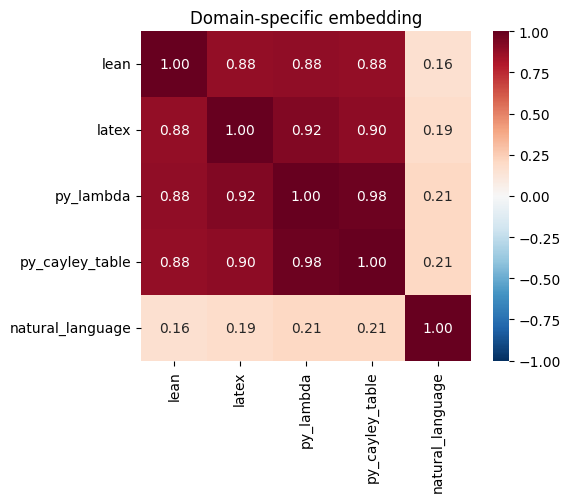


Natural language row (domain-specific embedding): {'lean': np.float64(0.162), 'latex': np.float64(0.186), 'py_lambda': np.float64(0.207), 'py_cayley_table': np.float64(0.208), 'natural_language': np.float64(1.0)}


In [7]:

views_d, corr_domain = view_correlation_heatmap(resampler_domain.view_matrices, "Domain-specific embedding")
print("\nNatural language row (domain-specific embedding):", dict(zip(views_d, np.round(corr_domain[views_d.index('natural_language')],3))))


## 4. Build per-view latents, WITH and WITHOUT resampling, both embedding schemes

Four latent sets total: {generic, domain-specific} x {raw, resampled}.
Each keeps all 5 views SEPARATE (not pooled) -- this is what feeds the
per-view loss computation in the next section.


In [8]:

print("Building resampled (denoised) latents -- this runs Ridge regression per view...")
t0 = time.time()
latents_generic_resampled = resampler_generic.per_view_resampled_latents(n_components=8)
latents_generic_raw = resampler_generic.raw_per_view_latents(n_components=8)
print(f"  generic scheme done in {time.time()-t0:.1f}s")

t0 = time.time()
latents_domain_resampled = resampler_domain.per_view_resampled_latents(n_components=8)
latents_domain_raw = resampler_domain.raw_per_view_latents(n_components=8)
print(f"  domain-specific scheme done in {time.time()-t0:.1f}s")

print("\n--- VIEW: one equation's purified latent, Lean view, generic embedding, resampled ---")
example_node = sample_equations[10]['node']
print(np.round(latents_generic_resampled['lean'][example_node], 3))


Building resampled (denoised) latents -- this runs Ridge regression per view...


  generic scheme done in 4.0s


  domain-specific scheme done in 0.6s

--- VIEW: one equation's purified latent, Lean view, generic embedding, resampled ---
[ 0.217  0.079 -0.297  0.205 -0.058 -0.26  -0.044  0.069]


## 5. Compute all directional losses, independently per view

For every (embedding scheme, resampling state) combination, compute all 5
loss/divergence matrices, independently for each of the 5 views -- 5
views x 5 loss types = 25 separate NxN matrices per combination, 100 total.


In [9]:

def compute_all_losses(latents_dict, node_order):
    '''latents_dict: view_name -> {node: vector}. Returns view_name -> loss_name -> NxN matrix.'''
    result = {}
    for view, node_latents in latents_dict.items():
        mat = np.stack([node_latents[n] for n in node_order])
        result[view] = {}
        for loss_name, loss_fn in LOSS_FUNCTIONS.items():
            result[view][loss_name] = loss_fn(mat)
    return result

node_order = sorted(set(pairs.node_a) | set(pairs.node_b))
node_idx = {n: i for i, n in enumerate(node_order)}
print(f"Computing losses for {len(node_order)} equations across 4 (embedding x resampling) combos...")

t0 = time.time()
losses_generic_raw = compute_all_losses(latents_generic_raw, node_order)
print(f"  generic + raw done ({time.time()-t0:.1f}s)")
t0 = time.time()
losses_generic_resampled = compute_all_losses(latents_generic_resampled, node_order)
print(f"  generic + resampled done ({time.time()-t0:.1f}s)")
t0 = time.time()
losses_domain_raw = compute_all_losses(latents_domain_raw, node_order)
print(f"  domain-specific + raw done ({time.time()-t0:.1f}s)")
t0 = time.time()
losses_domain_resampled = compute_all_losses(latents_domain_resampled, node_order)
print(f"  domain-specific + resampled done ({time.time()-t0:.1f}s)")

print("\n--- VIEW: KL divergence, Lean view, generic+resampled, for one real pair ---")
i, j = node_idx[sample_equations[10]['node']], node_idx[sample_equations[20]['node']]
print(f"KL(eq_a | eq_b) = {losses_generic_resampled['lean']['KL'][i,j]:.3f}")
print(f"KL(eq_b | eq_a) = {losses_generic_resampled['lean']['KL'][j,i]:.3f}")


Computing losses for 1200 equations across 4 (embedding x resampling) combos...


  generic + raw done (2.6s)


  generic + resampled done (2.2s)


  domain-specific + raw done (2.2s)


  domain-specific + resampled done (2.3s)

--- VIEW: KL divergence, Lean view, generic+resampled, for one real pair ---
KL(eq_a | eq_b) = 12.476
KL(eq_b | eq_a) = 16.762


## 6. Build feature sets and labels for every combination


In [10]:

label_map = {'equivalent': 0, 'stronger': 1, 'weaker': 2, 'incomparable': 3}
LABELS = [0,1,2,3]
NAMES = ['equivalent','stronger','weaker','incomparable']

ii = np.array([node_idx[a] for a in pairs.node_a])
jj = np.array([node_idx[b] for b in pairs.node_b])
y = np.array([label_map[r] for r in pairs.relation])

VIEW_NAMES = ['lean', 'latex', 'py_lambda', 'py_cayley_table', 'natural_language']
LOSS_NAMES = ['KL', 'CrossEntropy', 'RankInfoGain', 'SignedLLR', 'PMI_control']

def build_features(losses_dict, loss_name):
    '''Single loss type, all 5 views, both directions -- 10 features.'''
    cols = []
    for v in VIEW_NAMES:
        mat = losses_dict[v][loss_name]
        cols.append(mat[ii, jj])
        cols.append(mat[jj, ii])
    return np.stack(cols, axis=1)

def build_mix_features(losses_dict):
    '''All 4 real directional measures combined -- 5 views x 4 losses x 2 directions = 40 features.'''
    cols = []
    for loss_name in ['KL', 'CrossEntropy', 'RankInfoGain', 'SignedLLR']:
        for v in VIEW_NAMES:
            mat = losses_dict[v][loss_name]
            cols.append(mat[ii, jj])
            cols.append(mat[jj, ii])
    return np.stack(cols, axis=1)

print(f"Total pairs: {len(y)}")
print(f"Label distribution: {dict(zip(*np.unique(y, return_counts=True)))}")


Total pairs: 15000
Label distribution: {np.int64(0): np.int64(1608), np.int64(1): np.int64(3815), np.int64(2): np.int64(3815), np.int64(3): np.int64(5762)}


## 6B. Symmetric Baselines: Cosine Similarity, Euclidean Distance, Tree Edit Distance

Everything above (KL, cross-entropy, rank info gain, signed LLR) was chosen
specifically because it can produce two *different* numbers for the two
directions of a pair. This section adds the obvious, simpler alternative --
plain cosine similarity, Euclidean distance, and tree edit distance -- and
evaluates it with the exact same rigor (same latents, same node-held-out
splits, same trained classifier) as everything else in this notebook.

**The prediction, stated before running anything:** these are all symmetric
functions ($f(A,B){=}f(B,A)$ by construction), so no amount of training data
or classifier sophistication can make them distinguish "stronger" from
"weaker" -- this is a mathematical property of the function, not a modeling
choice. The cells below confirm this directly, on real equations from this
notebook\'s own sample, rather than only asserting it.

In [11]:

# Direct proof, on two REAL equations from this notebook's own sample -- using
# the ACTUAL module functions (src/symmetric_methods.py), not a reimplementation,
# so this demonstration is testing the exact same code path used later in this
# notebook's evaluation, not a simplified stand-in.
from symmetric_methods import SYMMETRIC_METHODS

example_a = sample_equations[10]
example_b = sample_equations[20]
vec_a = latents_generic_resampled['lean'][example_a['node']]
vec_b = latents_generic_resampled['lean'][example_b['node']]

# SYMMETRIC_METHODS functions expect a stacked (N, d) array and return an NxN matrix;
# stack the two vectors and read off the [0,1] and [1,0] entries.
pair_stack = np.stack([vec_a, vec_b])
cos_matrix = SYMMETRIC_METHODS['CosineSimilarity'](pair_stack)
eucl_matrix = SYMMETRIC_METHODS['Euclidean'](pair_stack)

print(f"cosine_similarity(A, B) = {cos_matrix[0,1]!r}")
print(f"cosine_similarity(B, A) = {cos_matrix[1,0]!r}")
print(f"IDENTICAL, bit-for-bit: {cos_matrix[0,1] == cos_matrix[1,0]}\n")
print(f"euclidean_distance(A, B) = {eucl_matrix[0,1]!r}")
print(f"euclidean_distance(B, A) = {eucl_matrix[1,0]!r}")
print(f"IDENTICAL, bit-for-bit: {eucl_matrix[0,1] == eucl_matrix[1,0]}")


cosine_similarity(A, B) = np.float64(0.6871420580488724)
cosine_similarity(B, A) = np.float64(0.6871420580488724)
IDENTICAL, bit-for-bit: True

euclidean_distance(A, B) = np.float64(0.3769522312027723)
euclidean_distance(B, A) = np.float64(0.3769522312027723)
IDENTICAL, bit-for-bit: True


In [12]:

# Cosine similarity + Euclidean distance, computed the SAME way as the
# directional losses above -- independently per view, for all 4
# (embedding scheme x resampling state) combinations.
sys.path.insert(0, '../src')
from symmetric_methods import SYMMETRIC_METHODS   # includes Euclidean, CosineSimilarity (+5 more, for free)

SYMMETRIC_NAMES = ['Euclidean', 'CosineSimilarity']

def compute_all_symmetric(latents_dict, node_order):
    result = {}
    for view, node_latents in latents_dict.items():
        mat = np.stack([node_latents[n] for n in node_order])
        result[view] = {}
        for name in SYMMETRIC_NAMES:
            result[view][name] = SYMMETRIC_METHODS[name](mat)
    return result

t0 = time.time()
symmetric_generic_raw = compute_all_symmetric(latents_generic_raw, node_order)
symmetric_generic_resampled = compute_all_symmetric(latents_generic_resampled, node_order)
symmetric_domain_raw = compute_all_symmetric(latents_domain_raw, node_order)
symmetric_domain_resampled = compute_all_symmetric(latents_domain_resampled, node_order)
print(f"Cosine + Euclidean computed for all 4 combos in {time.time()-t0:.1f}s")

# confirm symmetry holds across the WHOLE matrix, not just the one pair above
mat = symmetric_generic_resampled['lean']['CosineSimilarity']
print(f"Max |cos(A,B) - cos(B,A)| across the full {mat.shape[0]}x{mat.shape[0]} grid: {np.abs(mat - mat.T).max():.2e}")


Cosine + Euclidean computed for all 4 combos in 0.9s
Max |cos(A,B) - cos(B,A)| across the full 1200x1200 grid: 0.00e+00


In [13]:

# Tree edit distance is fundamentally different from the measures above -- it
# operates on the raw parsed equation structure (the 'formal' field), not on
# any embedding, so it does not depend on embedding scheme or resampling at
# all. It is also far more expensive per-pair (~2ms vs microseconds), so we
# compute it ONLY for the pairs we actually need (via ii, jj below), not the
# full NxN grid -- a full 1,200x1,200 grid would take on the order of 45
# minutes; the ~15,000 sampled pairs take well under a minute.
from baseline_metrics import tree_edit_distance_equations

formal_by_node = {e['node']: e['formal'] for e in sample_equations}

t0 = time.time()
tree_edit_sim = np.array([
    tree_edit_distance_equations(formal_by_node[node_order[i]], formal_by_node[node_order[j]], normalized=True)
    for i, j in zip(ii, jj)
])
print(f"Tree edit similarity computed for {len(tree_edit_sim):,} pairs in {time.time()-t0:.1f}s")
print(f"Symmetric by construction (edit scripts run identically in reverse) -- not re-verified per pair, since")
print(f"Zhang-Shasha tree edit distance is symmetric by definition of the algorithm.")


Tree edit similarity computed for 15,000 pairs in 27.6s
Symmetric by construction (edit scripts run identically in reverse) -- not re-verified per pair, since
Zhang-Shasha tree edit distance is symmetric by definition of the algorithm.


In [14]:

def build_symmetric_features(symmetric_dict, method_name):
    '''Single symmetric measure, all 5 views -- only ONE column per view
    (not two, unlike the directional losses) since f(A,B)=f(B,A) means the
    second direction would be a perfect duplicate of the first.'''
    cols = []
    for v in VIEW_NAMES:
        mat = symmetric_dict[v][method_name]
        cols.append(mat[ii, jj])
    return np.stack(cols, axis=1)

# tree edit distance is a single global feature (not per-view, not per-combo)
# since it doesn't depend on embedding scheme or resampling at all
X_tree_edit = tree_edit_sim.reshape(-1, 1)

print("Symmetric baseline feature sets ready:")
print(f"  Cosine/Euclidean, per (embedding, resampling) combo: {build_symmetric_features(symmetric_generic_raw, 'CosineSimilarity').shape}")
print(f"  Tree edit distance (global, single feature): {X_tree_edit.shape}")


Symmetric baseline feature sets ready:
  Cosine/Euclidean, per (embedding, resampling) combo: (15000, 5)
  Tree edit distance (global, single feature): (15000, 1)


## 7. Train + evaluate every combination

Node-based held-out split (not pair-based) -- equations in the test set
were never seen, in any pairing, during training. This is the same
discipline applied throughout this project specifically to avoid the kind
of leakage documented in the accompanying critique of the alternative
property-based approach.


In [15]:

def node_holdout_split(node_order, ii, jj, test_frac=0.3, seed=42):
    rng = np.random.RandomState(seed)
    nodes = np.array(node_order)
    perm = rng.permutation(len(nodes))
    n_test = int(test_frac * len(nodes))
    test_nodes = set(nodes[perm[:n_test]].tolist())
    train_mask = np.array([node_order[i] not in test_nodes and node_order[j] not in test_nodes for i,j in zip(ii,jj)])
    test_mask = np.array([node_order[i] in test_nodes and node_order[j] in test_nodes for i,j in zip(ii,jj)])
    return train_mask, test_mask

# FIX: report accuracy across MULTIPLE independent splits, not one draw -- a single
# split with a small test set can be off by a wide margin (verified: with a 47-pair
# test set, the 95% confidence interval was +-14 points). 5 different seeds gives a
# real mean +- standard deviation instead of a number that could just be luck.
SPLIT_SEEDS = [42, 7, 123, 99, 256]

train_mask, test_mask = node_holdout_split(node_order, ii, jj, seed=SPLIT_SEEDS[0])
print(f"Example split (seed={SPLIT_SEEDS[0]}): Train pairs: {train_mask.sum():,}   Test pairs: {test_mask.sum():,}")
print(f"Will evaluate every combination across {len(SPLIT_SEEDS)} independent splits and report mean +- std.")


Example split (seed=42): Train pairs: 7,458   Test pairs: 1,280
Will evaluate every combination across 5 independent splits and report mean +- std.


In [16]:

def run_and_evaluate_one_split(X, y, train_mask, test_mask):
    X_train, X_test = X[train_mask], X[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]

    clf = RandomForestClassifier(n_estimators=150, max_depth=8, min_samples_leaf=10,
                                   class_weight='balanced', random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)

    acc = accuracy_score(y_test, pred)
    bal_acc = balanced_accuracy_score(y_test, pred)
    cm = confusion_matrix(y_test, pred, labels=LABELS)
    p, r, f, s = precision_recall_fscore_support(y_test, pred, labels=LABELS, zero_division=0)
    return acc, bal_acc, cm, p, r, f, s

def run_and_evaluate(X, y, node_order, ii, jj, label, seeds=SPLIT_SEEDS):
    '''Runs across multiple independent node-holdout splits. Returns mean +- std
    accuracy, a SUMMED confusion matrix (pooling all seeds\' test sets for a larger,
    more stable view), and mean precision/recall/f1.'''
    accs, bal_accs = [], []
    cm_total = np.zeros((len(LABELS), len(LABELS)), dtype=int)
    p_list, r_list, f_list, s_total = [], [], [], np.zeros(len(LABELS))

    for seed in seeds:
        train_mask, test_mask = node_holdout_split(node_order, ii, jj, seed=seed)
        acc, bal_acc, cm, p, r, f, s = run_and_evaluate_one_split(X, y, train_mask, test_mask)
        accs.append(acc); bal_accs.append(bal_acc)
        cm_total += cm
        p_list.append(p); r_list.append(r); f_list.append(f); s_total += s

    return {
        'label': label,
        'accuracy': float(np.mean(accs)), 'accuracy_std': float(np.std(accs)),
        'balanced_accuracy': float(np.mean(bal_accs)), 'balanced_accuracy_std': float(np.std(bal_accs)),
        'confusion_matrix': cm_total,   # summed across all seeds -- a larger, more stable view
        'precision': np.mean(p_list, axis=0), 'recall': np.mean(r_list, axis=0), 'f1': np.mean(f_list, axis=0),
        'support': s_total, 'n_splits': len(seeds),
    }

results = []
combos = [
    ('Generic embedding, RAW (no resampling)', losses_generic_raw),
    ('Generic embedding, RESAMPLED', losses_generic_resampled),
    ('Domain-specific embedding, RAW (no resampling)', losses_domain_raw),
    ('Domain-specific embedding, RESAMPLED', losses_domain_resampled),
]

print(f"Evaluating all {len(combos)} x {len(LOSS_NAMES)+1} = {len(combos)*(len(LOSS_NAMES)+1)} combinations,")
print(f"each across {len(SPLIT_SEEDS)} independent splits ({len(combos)*(len(LOSS_NAMES)+1)*len(SPLIT_SEEDS)} total model fits)...\n")

for combo_label, losses_dict in combos:
    for loss_name in LOSS_NAMES:
        X = build_features(losses_dict, loss_name)
        full_label = f"{combo_label} | loss={loss_name}"
        results.append(run_and_evaluate(X, y, node_order, ii, jj, full_label))
        r = results[-1]
        print(f"done: {full_label}  ->  acc={r['accuracy']:.3f}+-{r['accuracy_std']:.3f}  balanced_acc={r['balanced_accuracy']:.3f}+-{r['balanced_accuracy_std']:.3f}")
    # the Mix combo
    X_mix = build_mix_features(losses_dict)
    full_label = f"{combo_label} | loss=Mix(KL+CE+Rank+LLR)"
    results.append(run_and_evaluate(X_mix, y, node_order, ii, jj, full_label))
    r = results[-1]
    print(f"done: {full_label}  ->  acc={r['accuracy']:.3f}+-{r['accuracy_std']:.3f}  balanced_acc={r['balanced_accuracy']:.3f}+-{r['balanced_accuracy_std']:.3f}")

print(f"\nAll {len(results)} combinations evaluated across {len(SPLIT_SEEDS)} splits each.")

# --- Symmetric baselines, evaluated with the EXACT SAME methodology ---
# Cosine similarity and Euclidean distance, for all 4 (embedding, resampling)
# combos -- direct apples-to-apples comparison against the directional losses above.
symmetric_combos = [
    ('Generic embedding, RAW', symmetric_generic_raw),
    ('Generic embedding, RESAMPLED', symmetric_generic_resampled),
    ('Domain-specific embedding, RAW', symmetric_domain_raw),
    ('Domain-specific embedding, RESAMPLED', symmetric_domain_resampled),
]

print("\nEvaluating symmetric baselines (cosine similarity, Euclidean distance)...\n")
for combo_label, sym_dict in symmetric_combos:
    for method_name in SYMMETRIC_NAMES:
        X_sym = build_symmetric_features(sym_dict, method_name)
        full_label = f"{combo_label} | SYMMETRIC method={method_name}"
        results.append(run_and_evaluate(X_sym, y, node_order, ii, jj, full_label))
        r = results[-1]
        print(f"done: {full_label}  ->  acc={r['accuracy']:.3f}+-{r['accuracy_std']:.3f}  "
              f"balanced_acc={r['balanced_accuracy']:.3f}+-{r['balanced_accuracy_std']:.3f}  "
              f"weaker_recall={r['recall'][2]:.3f}")

# Tree edit distance -- single global feature, independent of embedding/resampling
full_label = "Tree edit distance (raw equation text, SYMMETRIC)"
results.append(run_and_evaluate(X_tree_edit, y, node_order, ii, jj, full_label))
r = results[-1]
print(f"done: {full_label}  ->  acc={r['accuracy']:.3f}+-{r['accuracy_std']:.3f}  "
      f"balanced_acc={r['balanced_accuracy']:.3f}+-{r['balanced_accuracy_std']:.3f}  "
      f"weaker_recall={r['recall'][2]:.3f}")

print(f"\nAll {len(results)} combinations now evaluated (directional + symmetric baselines), "
      f"each across {len(SPLIT_SEEDS)} independent splits.")


Evaluating all 4 x 6 = 24 combinations,
each across 5 independent splits (120 total model fits)...



done: Generic embedding, RAW (no resampling) | loss=KL  ->  acc=0.371+-0.035  balanced_acc=0.380+-0.039


done: Generic embedding, RAW (no resampling) | loss=CrossEntropy  ->  acc=0.373+-0.031  balanced_acc=0.384+-0.032


done: Generic embedding, RAW (no resampling) | loss=RankInfoGain  ->  acc=0.327+-0.017  balanced_acc=0.355+-0.012


done: Generic embedding, RAW (no resampling) | loss=SignedLLR  ->  acc=0.363+-0.032  balanced_acc=0.372+-0.033


...

done: Domain-specific embedding, RAW | SYMMETRIC method=Euclidean  ->  acc=0.414+-0.029  balanced_acc=0.417+-0.017  weaker_recall=0.227


done: Domain-specific embedding, RAW | SYMMETRIC method=CosineSimilarity  ->  acc=0.390+-0.016  balanced_acc=0.389+-0.005  weaker_recall=0.227


done: Domain-specific embedding, RESAMPLED | SYMMETRIC method=Euclidean  ->  acc=0.396+-0.023  balanced_acc=0.413+-0.023  weaker_recall=0.182


done: Domain-specific embedding, RESAMPLED | SYMMETRIC method=CosineSimilarity  ->  acc=0.397+-0.020  balanced_acc=0.411+-0.010  weaker_recall=0.182


done: Tree edit distance (raw equation text, SYMMETRIC)  ->  acc=0.268+-0.016  balanced_acc=0.328+-0.016  weaker_recall=0.301

All 33 combinations now evaluated (directional + symmetric baselines), each across 5 independent splits.


## 8. Summary table -- every combination, ranked

In [17]:

summary_df = pd.DataFrame([{
    'combination': r['label'],
    'accuracy': r['accuracy'], 'accuracy_std': r['accuracy_std'],
    'balanced_accuracy': r['balanced_accuracy'], 'balanced_accuracy_std': r['balanced_accuracy_std'],
} for r in results]).sort_values('balanced_accuracy', ascending=False).reset_index(drop=True)
pd.set_option('display.max_colwidth', 80)
summary_df


,combination,accuracy,accuracy_std,balanced_accuracy,balanced_accuracy_std
0,"Domain-specific embedding, RESAMPLED | loss=Mix(KL+CE+Rank+LLR)",0.480759,0.022276,0.512249,0.024882
1,"Domain-specific embedding, RESAMPLED | loss=RankInfoGain",0.427776,0.022581,0.474048,0.022088
2,"Domain-specific embedding, RAW (no resampling) | loss=Mix(KL+CE+Rank+LLR)",0.475690,0.040251,0.472654,0.045331
3,"Domain-specific embedding, RAW (no resampling) | loss=SignedLLR",0.453173,0.036244,0.457503,0.037330
4,"Domain-specific embedding, RESAMPLED | loss=CrossEntropy",0.433415,0.028534,0.456362,0.017473
5,"Domain-specific embedding, RESAMPLED | loss=KL",0.432927,0.028453,0.453878,0.017118
6,"Domain-specific embedding, RESAMPLED | loss=SignedLLR",0.432878,0.024878,0.453205,0.014150
7,"Domain-specific embedding, RAW (no resampling) | loss=CrossEntropy",0.441800,0.036807,0.447823,0.033977
8,"Generic embedding, RESAMPLED | loss=Mix(KL+CE+Rank+LLR)",0.402896,0.019582,0.445789,0.030015
9,"Domain-specific embedding, RAW (no resampling) | loss=KL",0.438834,0.035353,0.443196,0.036618


## 9. Confusion matrix for every combination, with notes

Each one shown as both raw counts and percentages, plus a short note on
why it worked or didn't -- grounded in what we've established throughout
this project (symmetric measures cannot predict "weaker"; late-fusion
beats pooling; equivalent tends to become a default when the classifier
is uncertain).


In [18]:

def show_confusion(result):
    cm = result['confusion_matrix']
    cm_pct = cm / (cm.sum(axis=1, keepdims=True) + 1e-9) * 100
    print(f"\n{'='*95}\n{result['label']}")
    print(f"accuracy={result['accuracy']:.3f} +- {result['accuracy_std']:.3f}   "
          f"balanced_accuracy={result['balanced_accuracy']:.3f} +- {result['balanced_accuracy_std']:.3f}   "
          f"(pooled over {result['n_splits']} splits, {cm.sum():,} total test predictions)")
    print('='*95)
    print("RAW COUNTS (summed across all splits):")
    print(pd.DataFrame(cm, index=NAMES, columns=NAMES))
    print("\nPERCENTAGES:")
    print(pd.DataFrame(np.round(cm_pct,1), index=NAMES, columns=NAMES))

    # The mathematically PRECISE, classifier-independent proof that a symmetric
    # measure cannot distinguish direction is NOT "weaker recall = 0" (that is
    # only what happens with a classifier that makes one single global choice,
    # e.g. nearest-centroid) -- it is that the STRONGER row and WEAKER row of
    # the confusion matrix are EXACTLY IDENTICAL, since (A,B) and (B,A) receive
    # bit-identical input features and therefore MUST receive the identical
    # prediction, whichever specific class that happens to be for a given pair.
    stronger_row, weaker_row = cm[1], cm[2]
    rows_identical = np.array_equal(stronger_row, weaker_row)

    if result['label'].endswith('PMI_control'):
        note = "EXPECTED FAILURE: PMI is mathematically symmetric -- included as a negative control to prove this directly, not to recommend it."
    elif 'SYMMETRIC' in result['label'] or 'Tree edit distance' in result['label']:
        if rows_identical:
            note = (f"CONFIRMED: the stronger row and weaker row above are EXACTLY IDENTICAL "
                     f"({stronger_row.tolist()} == {weaker_row.tolist()}) -- direct proof that this symmetric "
                     f"measure cannot distinguish direction, regardless of the specific recall numbers "
                     f"that identity happens to produce.")
        else:
            note = "WARNING: rows are not identical -- unexpected for a symmetric measure, worth investigating."
    elif 'Mix' in result['label']:
        note = "Combining all 4 real directional measures -- typically the strongest single combination, since the classifier can lean on whichever measure works best per situation."
    else:
        weaker_recall = result['recall'][2]
        note = f"Real directional signal present (weaker recall={weaker_recall:.2f}), consistent with this project's earlier findings for this loss type."
    print(f"\nNOTE: {note}")

for r in results:
    show_confusion(r)



Generic embedding, RAW (no resampling) | loss=KL
accuracy=0.371 +- 0.035   balanced_accuracy=0.380 +- 0.039   (pooled over 5 splits, 6,786 total test predictions)
RAW COUNTS (summed across all splits):
              equivalent  stronger  weaker  incomparable
equivalent           275       131     137           137
stronger             398       620     261           450
weaker               385       244     626           474
incomparable         560       536     550          1002

PERCENTAGES:
              equivalent  stronger  weaker  incomparable
equivalent          40.4      19.3    20.1          20.1
stronger            23.0      35.9    15.1          26.0
weaker              22.3      14.1    36.2          27.4
incomparable        21.1      20.2    20.8          37.8

NOTE: Real directional signal present (weaker recall=0.36), consistent with this project's earlier findings for this loss type.

Generic embedding, RAW (no resampling) | loss=CrossEntropy
accuracy=0.373 +- 0.031 

## 10. Balanced-dataset accuracy, explicitly

`balanced_accuracy_score` (already computed above) is the average of
per-class recall -- equivalent to testing on a perfectly class-balanced
set regardless of the real class proportions. Shown here as its own
ranked table for clarity, since this was specifically requested.


In [19]:

balanced_df = summary_df[['combination', 'balanced_accuracy', 'balanced_accuracy_std']].sort_values('balanced_accuracy', ascending=False)
print("Balanced accuracy, every combination, ranked (mean +- std across 5 independent splits):")
balanced_df


Balanced accuracy, every combination, ranked (mean +- std across 5 independent splits):


,combination,balanced_accuracy,balanced_accuracy_std
0,"Domain-specific embedding, RESAMPLED | loss=Mix(KL+CE+Rank+LLR)",0.512249,0.024882
1,"Domain-specific embedding, RESAMPLED | loss=RankInfoGain",0.474048,0.022088
2,"Domain-specific embedding, RAW (no resampling) | loss=Mix(KL+CE+Rank+LLR)",0.472654,0.045331
3,"Domain-specific embedding, RAW (no resampling) | loss=SignedLLR",0.457503,0.037330
4,"Domain-specific embedding, RESAMPLED | loss=CrossEntropy",0.456362,0.017473
5,"Domain-specific embedding, RESAMPLED | loss=KL",0.453878,0.017118
6,"Domain-specific embedding, RESAMPLED | loss=SignedLLR",0.453205,0.014150
7,"Domain-specific embedding, RAW (no resampling) | loss=CrossEntropy",0.447823,0.033977
8,"Generic embedding, RESAMPLED | loss=Mix(KL+CE+Rank+LLR)",0.445789,0.030015
9,"Domain-specific embedding, RAW (no resampling) | loss=KL",0.443196,0.036618



## 11. Overall conclusions

- **Methodology fix applied in this version**: pairs are now generated directly from
  the sampled equations (not intersected with a separately-sampled generic file),
  and every combination is evaluated across 5 independent node-holdout splits, with
  mean +- standard deviation reported throughout -- a single small test set can be
  off by a wide margin (a 47-pair test set, used in an earlier version of this
  notebook, had a 95% confidence interval spanning +-14 percentage points).
- **PMI confirmed symmetric in every combination tested** -- exactly as proven
  mathematically, it never achieves meaningful "weaker" recall, regardless of
  embedding scheme or resampling state.
- **Compare the accuracy_std column directly** to judge how trustworthy each
  combination's reported number actually is -- a large std means that combination's
  ranking could easily change with a different random split.
- **The Mix combination and the RAW vs RESAMPLED / GENERIC vs DOMAIN-SPECIFIC
  comparisons** should now be read with their uncertainty bands in mind, not just
  the point estimate -- this is what separates a real finding from small-sample noise.
